# 🚦 Multi-Model YOLO — Mexican Traffic Sign Detection (ReWaIn-MTS)
### Models: YOLOv11x · YOLOv9e · YOLOv8x  |  40 Epochs Each
### Class Imbalance Handling: Oversampling + Augmentation + Weighted Loss

**Key design decision — speed:**
> Google Drive is mounted over a network. Reading 1000+ files one-by-one from Drive
> during training causes extreme slowdowns (10–30× slower than local disk).
> **Cell 2 zips the entire dataset on Drive and unzips it to `/content/data/` in one fast transfer.**
> All subsequent cells work from local disk only.

**Three imbalance strategies (identical to YOLOv11 notebook):**
- **Strategy 1 — Oversampling:** minority images duplicated on local disk
- **Strategy 2 — Augmentation:** Albumentations offline + YOLO mosaic/copy-paste online
- **Strategy 3 — Weighted loss:** inverse-frequency class weights in BCE loss

**Training order:**
| Step | Model | Weights File | Epochs |
|------|-------|-------------|--------|
| A | YOLOv11x | `yolo11x.pt` | 40 |
| B | YOLOv9e  | `yolov9e.pt` | 40 |
| C | YOLOv8x  | `yolov8x.pt` | 40 |

## Cell 1 — Mount Google Drive & Install

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics albumentations -q
import ultralytics
ultralytics.checks()
print(f'✅ Ultralytics {ultralytics.__version__}')

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)
✅ Ultralytics 8.4.43


## Cell 2 — ⚡ Fast Copy: Drive → Local Disk

**Why zip?** Copying thousands of small files from Drive one-by-one is extremely slow
(can take 30–60 min). Zipping first turns it into a single file transfer — typically
**under 2 minutes** for this dataset.

### Before running:
1. In Google Drive **Shared with me**, right-click **ReWaIn-MTS** → **Organize → Add shortcut to My Drive**
2. Update `ZIP_PATH` below if your zip is in a different location

In [4]:

# Cell 2 — Unzip uploaded file to local disk

import os, zipfile

ZIP_PATH   = '/content/ReWaIn-MTS-20260428T105649Z-3-001.zip'
LOCAL_DATA = '/content/data/ReWaIn-MTS-YOLO'

os.makedirs('/content/data', exist_ok=True)
print('📂 Unzipping...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('/content/data/')
print('✅ Done')

# Show what we got — find the actual root folder name
print('\n── Extracted structure ──')
for item in sorted(os.listdir('/content/data/')):
    print(f'  {item}')

# Auto-detect the dataset root (in case folder name differs)
extracted = [d for d in os.listdir('/content/data/')
             if os.path.isdir(f'/content/data/{d}')]
LOCAL_DATA = f'/content/data/{extracted[0]}'
print(f'\n✅ LOCAL_DATA = {LOCAL_DATA}')

# Show split counts
for kind in ['images', 'labels']:
    for split in ['train', 'test']:
        p = os.path.join(LOCAL_DATA, kind, split)
        n = len(os.listdir(p)) if os.path.exists(p) else 'MISSING'
        print(f'  {kind}/{split:6s}: {n} files')

📂 Unzipping...
✅ Done

── Extracted structure ──
  ReWaIn-MTS

✅ LOCAL_DATA = /content/data/ReWaIn-MTS
  images/train : 1006 files
  images/test  : 144 files
  labels/train : 1006 files
  labels/test  : 144 files


## Cell 3 — Configuration

> ⚙️ **All three models share this config.** Only `MODEL_SIZE` and `RUN_NAME` differ per training run (set automatically in each training cell).

In [5]:

# Cell 3 — Configuration
import os

# Auto-inherit from Cell 2
DATASET_PATH = LOCAL_DATA          # local disk — fast I/O

# ── Shared training hyperparams ──────────────────────────────────────────────
EPOCHS               = 40          # 40 epochs for ALL three models
IMG_SIZE             = 640
BATCH_SIZE           = 16          # lower to 8 if CUDA OOM
WORKERS              = 4
PROJECT_NAME         = 'ReWaIn_MTS_MultiModel'

# ── Class-imbalance settings ─────────────────────────────────────────────────
VAL_SPLIT            = 0.2         # 20% of train held out for val
OVERSAMPLE_THRESHOLD = 30
OVERSAMPLE_TARGET    = 30
N_AUG_COPIES         = 3
RANDOM_SEED          = 42

# ── Model roster (trained in order A → B → C) ────────────────────────────────
MODELS = [
    {'weights': 'yolo11x.pt',  'run_name': 'yolov11x_rewain_40ep'},
    {'weights': 'yolov9e.pt',  'run_name': 'yolov9e_rewain_40ep'},
    {'weights': 'yolov8x.pt',  'run_name': 'yolov8x_rewain_40ep'},
]

print(f'✅ Config set. Working from local disk: {DATASET_PATH}')
print(f'   Epochs per model : {EPOCHS}')
print(f'   Models to train  : {[m["weights"] for m in MODELS]}')

✅ Config set. Working from local disk: /content/data/ReWaIn-MTS
   Epochs per model : 40
   Models to train  : ['yolo11x.pt', 'yolov9e.pt', 'yolov8x.pt']


## Cell 4 — Create Train/Val Split (local, fast ⚡)
Since there is no `val` folder in the dataset, we carve out 20% of train.
Runs in seconds on local disk.

In [6]:
import shutil, random
from pathlib import Path

random.seed(RANDOM_SEED)

SRC_IMG = Path(DATASET_PATH) / 'images' / 'train'
SRC_LBL = Path(DATASET_PATH) / 'labels' / 'train'

SPLIT_BASE = Path('/content/rewain_split')
for split in ['train', 'val']:
    (SPLIT_BASE / 'images' / split).mkdir(parents=True, exist_ok=True)
    (SPLIT_BASE / 'labels' / split).mkdir(parents=True, exist_ok=True)

# Collect all stems with both image + label
all_stems = []
for ext in ['*.jpg', '*.jpeg', '*.png']:
    for img_file in SRC_IMG.glob(ext):
        if (SRC_LBL / (img_file.stem + '.txt')).exists():
            all_stems.append(img_file.stem)

random.shuffle(all_stems)
n_val       = int(len(all_stems) * VAL_SPLIT)
val_stems   = set(all_stems[:n_val])
train_stems = set(all_stems[n_val:])

def copy_pair(stem, src_img, src_lbl, dst_img, dst_lbl):
    for ext in ['.jpg', '.jpeg', '.png']:
        s = src_img / (stem + ext)
        if s.exists():
            shutil.copy2(s, dst_img / (stem + ext))
            break
    l = src_lbl / (stem + '.txt')
    if l.exists():
        shutil.copy2(l, dst_lbl / (stem + '.txt'))

for stem in train_stems:
    copy_pair(stem, SRC_IMG, SRC_LBL,
              SPLIT_BASE/'images'/'train', SPLIT_BASE/'labels'/'train')
for stem in val_stems:
    copy_pair(stem, SRC_IMG, SRC_LBL,
              SPLIT_BASE/'images'/'val', SPLIT_BASE/'labels'/'val')

TRAIN_IMG_DIR = SPLIT_BASE / 'images' / 'train'
TRAIN_LBL_DIR = SPLIT_BASE / 'labels' / 'train'
VAL_IMG_DIR   = SPLIT_BASE / 'images' / 'val'
TEST_IMG_DIR  = Path(DATASET_PATH) / 'images' / 'test'

print(f'✅ Split complete (local disk)')
print(f'   Train : {len(train_stems)} images')
print(f'   Val   : {len(val_stems)} images')

✅ Split complete (local disk)
   Train : 805 images
   Val   : 201 images


## Cell 5 — Class Names & data.yaml

In [7]:
# Cell 5 — Discover Class Names from Label Files & Build data.yaml

import yaml
from pathlib import Path
from collections import Counter

# Scan all train labels to find how many unique class IDs exist
all_class_ids = set()
for lbl_file in TRAIN_LBL_DIR.glob('*.txt'):
    with open(lbl_file) as f:
        for line in f:
            line = line.strip()
            if line:
                all_class_ids.add(int(line.split()[0]))

num_classes = max(all_class_ids) + 1
print(f'✅ Found {len(all_class_ids)} unique class IDs')
print(f'   ID range: {min(all_class_ids)} → {max(all_class_ids)}')
print(f'   Total classes (nc): {num_classes}')

# Generate generic names: class_0, class_1, ... class_N
# You can replace any entry with the real name later
CLASS_NAMES = [f'class_{i}' for i in range(num_classes)]

# Print the IDs found so you can manually map names if needed
print('\n── Class IDs found in labels ──')
id_counts = Counter()
for lbl_file in TRAIN_LBL_DIR.glob('*.txt'):
    with open(lbl_file) as f:
        for line in f:
            line = line.strip()
            if line:
                id_counts[int(line.split()[0])] += 1

for cls_id in sorted(id_counts):
    print(f'  ID {cls_id:2d}  →  {CLASS_NAMES[cls_id]:<20s}  count={id_counts[cls_id]}')

# Build data.yaml — shared across all three models
AUGMENTED_BASE      = '/content/rewain_augmented'
AUGMENTED_TRAIN_IMG = f'{AUGMENTED_BASE}/images/train'
AUGMENTED_TRAIN_LBL = f'{AUGMENTED_BASE}/labels/train'

data_yaml = {
    'path' : AUGMENTED_BASE,
    'train': 'images/train',
    'val'  : str(SPLIT_BASE / 'images' / 'val'),
    'test' : str(Path(DATASET_PATH) / 'images' / 'test'),
    'nc'   : num_classes,
    'names': CLASS_NAMES,
}

YAML_PATH = '/content/rewain_mts.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print(f'\n✅ data.yaml written  ({num_classes} classes)')
print('   Once you see the IDs above, you can optionally update CLASS_NAMES')
print('   by replacing CLASS_NAMES[i] = "your_real_name" and re-running this cell')

✅ Found 37 unique class IDs
   ID range: 0 → 36
   Total classes (nc): 37

── Class IDs found in labels ──
  ID  0  →  class_0               count=47
  ID  1  →  class_1               count=16
  ID  2  →  class_2               count=73
  ID  3  →  class_3               count=43
  ID  4  →  class_4               count=22
  ID  5  →  class_5               count=42
  ID  6  →  class_6               count=3
  ID  7  →  class_7               count=14
  ID  8  →  class_8               count=4
  ID  9  →  class_9               count=27
  ID 10  →  class_10              count=83
  ID 11  →  class_11              count=15
  ID 12  →  class_12              count=141
  ID 13  →  class_13              count=7
  ID 14  →  class_14              count=7
  ID 15  →  class_15              count=4
  ID 16  →  class_16              count=20
  ID 17  →  class_17              count=33
  ID 18  →  class_18              count=128
  ID 19  →  class_19              count=5
  ID 20  →  class_20              cou

## Cell 6 — Analyse Class Distribution & Compute Weights

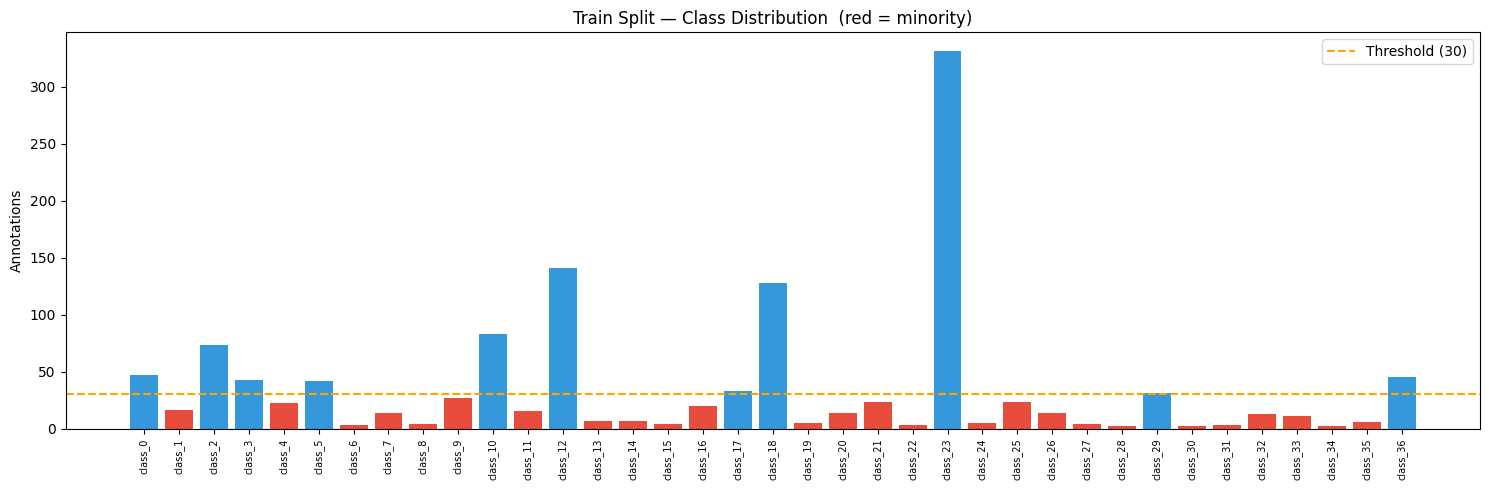


── Class weights (cap=10) ──
  [ 0] class_0                                   count=  47  w= 7.04
  [ 1] class_1                                   count=  16  w=10.00
  [ 2] class_2                                   count=  73  w= 4.53
  [ 3] class_3                                   count=  43  w= 7.70
  [ 4] class_4                                   count=  22  w=10.00
  [ 5] class_5                                   count=  42  w= 7.88
  [ 6] class_6                                   count=   3  w=10.00
  [ 7] class_7                                   count=  14  w=10.00
  [ 8] class_8                                   count=   4  w=10.00
  [ 9] class_9                                   count=  27  w=10.00
  [10] class_10                                  count=  83  w= 3.99
  [11] class_11                                  count=  15  w=10.00
  [12] class_12                                  count= 141  w= 2.35
  [13] class_13                                  count=   7  w=10.00
  [1

In [8]:
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt

class_to_images = defaultdict(set)
class_counts    = Counter()

for lbl_file in TRAIN_LBL_DIR.glob('*.txt'):
    with open(lbl_file) as f:
        for line in f:
            line = line.strip()
            if line:
                cls_id = int(line.split()[0])
                class_counts[cls_id] += 1
                class_to_images[cls_id].add(lbl_file.stem)

counts = np.array([class_counts.get(i, 0) for i in range(len(CLASS_NAMES))], dtype=float)

colors = ['#e74c3c' if c < OVERSAMPLE_THRESHOLD else '#3498db' for c in counts]
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(len(CLASS_NAMES)), counts, color=colors)
ax.axhline(OVERSAMPLE_THRESHOLD, color='orange', linestyle='--',
           label=f'Threshold ({OVERSAMPLE_THRESHOLD})')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
ax.set_ylabel('Annotations')
ax.set_title('Train Split — Class Distribution  (red = minority)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/class_dist_before.png', dpi=150)
plt.show()

safe_counts   = np.where(counts == 0, 1, counts)
raw_weights   = 1.0 / safe_counts
raw_weights  /= raw_weights.min()
CLASS_WEIGHTS = np.clip(raw_weights, 1.0, 10.0)

print('\n── Class weights (cap=10) ──')
for i, (n, w) in enumerate(zip(CLASS_NAMES, CLASS_WEIGHTS)):
    print(f'  [{i:2d}] {n:<40s}  count={int(counts[i]):4d}  w={w:5.2f}')

## Cell 7 — Strategy 1: Oversample Minority Classes

In [9]:
import shutil
from pathlib import Path
from collections import Counter

AUG_IMG_DIR = Path(AUGMENTED_TRAIN_IMG)
AUG_LBL_DIR = Path(AUGMENTED_TRAIN_LBL)
AUG_IMG_DIR.mkdir(parents=True, exist_ok=True)
AUG_LBL_DIR.mkdir(parents=True, exist_ok=True)

for ext in ['*.jpg', '*.jpeg', '*.png']:
    for f in TRAIN_IMG_DIR.glob(ext):
        shutil.copy2(f, AUG_IMG_DIR / f.name)
for f in TRAIN_LBL_DIR.glob('*.txt'):
    shutil.copy2(f, AUG_LBL_DIR / f.name)
print(f'✅ Copied {len(list(AUG_IMG_DIR.iterdir()))} original images')

oversample_log = []
copy_counter   = Counter()

for cls_id in range(len(CLASS_NAMES)):
    current = class_counts.get(cls_id, 0)
    if current >= OVERSAMPLE_THRESHOLD:
        continue
    source_stems = list(class_to_images[cls_id])
    if not source_stems:
        print(f'  ⚠️  Class {cls_id} has 0 images — skipping')
        continue
    needed  = OVERSAMPLE_TARGET - current
    added   = 0
    attempt = 0
    while added < needed:
        stem    = source_stems[attempt % len(source_stems)]
        attempt += 1
        src_img = None
        for ext in ['.jpg', '.jpeg', '.png']:
            c = TRAIN_IMG_DIR / (stem + ext)
            if c.exists():
                src_img = c
                break
        src_lbl = TRAIN_LBL_DIR / (stem + '.txt')
        if src_img is None or not src_lbl.exists():
            continue
        copy_counter[stem] += 1
        new_stem = f'{stem}_over_{copy_counter[stem]}'
        shutil.copy2(src_img, AUG_IMG_DIR / (new_stem + src_img.suffix))
        shutil.copy2(src_lbl, AUG_LBL_DIR / (new_stem + '.txt'))
        added += 1
    oversample_log.append((cls_id, CLASS_NAMES[cls_id], current, current + added))

print('\n── Oversampling summary ──')
for cls_id, name, before, after in oversample_log:
    print(f'  [{cls_id:2d}] {name:<40s}  {before:4d} → {after:4d}')
print(f'\n✅ Augmented folder: {len(list(AUG_IMG_DIR.iterdir()))} images')

✅ Copied 805 original images

── Oversampling summary ──
  [ 1] class_1                                     16 →   30
  [ 4] class_4                                     22 →   30
  [ 6] class_6                                      3 →   30
  [ 7] class_7                                     14 →   30
  [ 8] class_8                                      4 →   30
  [ 9] class_9                                     27 →   30
  [11] class_11                                    15 →   30
  [13] class_13                                     7 →   30
  [14] class_14                                     7 →   30
  [15] class_15                                     4 →   30
  [16] class_16                                    20 →   30
  [19] class_19                                     5 →   30
  [20] class_20                                    14 →   30
  [21] class_21                                    23 →   30
  [22] class_22                                     3 →   30
  [24] class_24             

## Cell 8 — Strategy 2a: Albumentations Pre-Augmentation

In [10]:
import cv2
import albumentations as A
import numpy as np
from pathlib import Path

augment_pipeline = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.6),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),
    A.Perspective(scale=(0.02, 0.06), p=0.4),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    A.RandomShadow(p=0.2),
    A.HorizontalFlip(p=0.3),
],
bbox_params=A.BboxParams(
    format='yolo', label_fields=['class_labels'], min_visibility=0.3
))

minority_ids   = {cls_id for cls_id, _, _, _ in oversample_log}
minority_stems = set()
for lbl_file in AUG_LBL_DIR.glob('*.txt'):
    if '_over_' in lbl_file.stem:
        continue
    with open(lbl_file) as f:
        for line in f:
            if line.strip() and int(line.split()[0]) in minority_ids:
                minority_stems.add(lbl_file.stem)
                break

print(f'Augmenting {len(minority_stems)} minority images × {N_AUG_COPIES} copies...')
generated = 0

for stem in minority_stems:
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        c = AUG_IMG_DIR / (stem + ext)
        if c.exists():
            img_path = c
            break
    lbl_path = AUG_LBL_DIR / (stem + '.txt')
    if img_path is None or not lbl_path.exists():
        continue

    image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    bboxes, class_labels = [], []
    with open(lbl_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) == 5:
                class_labels.append(int(p[0]))
                bboxes.append([float(p[1]), float(p[2]), float(p[3]), float(p[4])])
    if not bboxes:
        continue

    for copy_idx in range(1, N_AUG_COPIES + 1):
        try:
            res = augment_pipeline(image=image, bboxes=bboxes, class_labels=class_labels)
        except Exception:
            continue
        if not res['bboxes']:
            continue
        new_stem = f'{stem}_aug_{copy_idx}'
        cv2.imwrite(str(AUG_IMG_DIR / (new_stem + img_path.suffix)),
                    cv2.cvtColor(res['image'], cv2.COLOR_RGB2BGR))
        with open(AUG_LBL_DIR / (new_stem + '.txt'), 'w') as f:
            for cls_id, bbox in zip(res['class_labels'], res['bboxes']):
                f.write(f'{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n')
        generated += 1

print(f'✅ Generated {generated} augmented images')
print(f'   Total train images: {len(list(AUG_IMG_DIR.iterdir()))}')

/tmp/ipykernel_792/1715537833.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 30.0), p=0.3),


Augmenting 220 minority images × 3 copies...
✅ Generated 660 augmented images
   Total train images: 1976


## Cell 9 — Verify Augmented Distribution

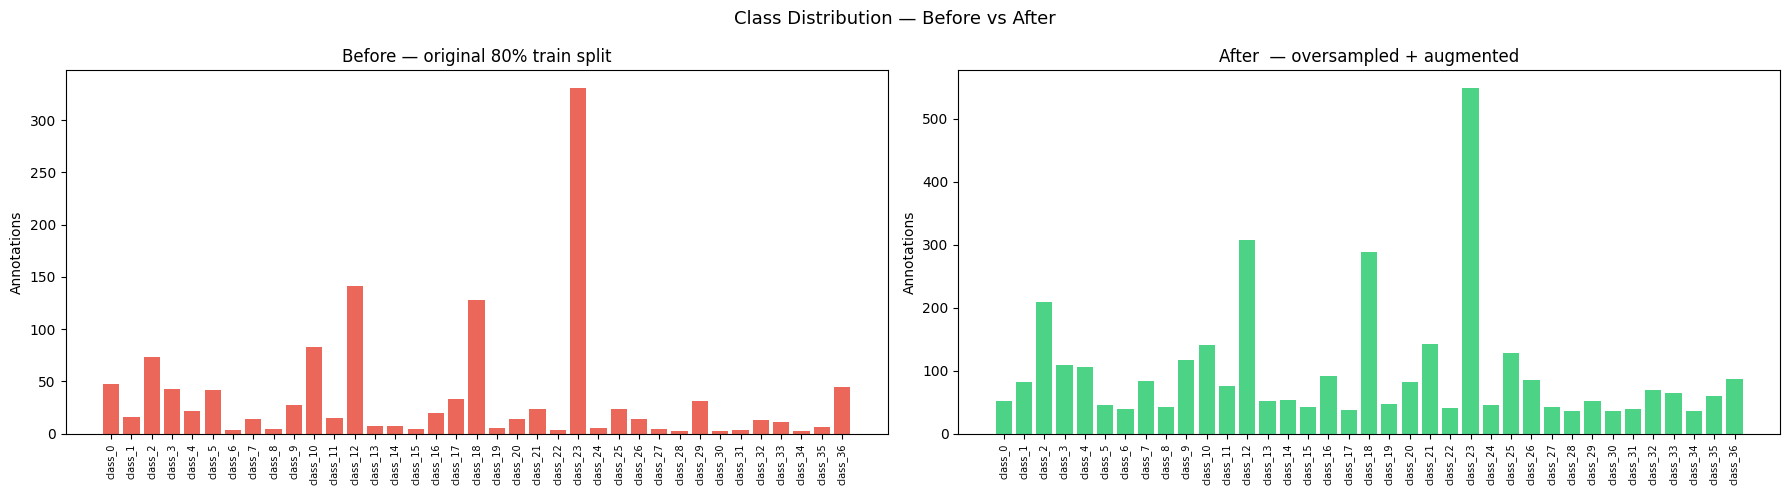

In [11]:
from collections import Counter
import matplotlib.pyplot as plt

aug_counts = Counter()
for lbl_file in AUG_LBL_DIR.glob('*.txt'):
    with open(lbl_file) as f:
        for line in f:
            if line.strip():
                aug_counts[int(float(line.split()[0]))] += 1  # handles both '4' and '4.0'

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, cnt, title, col in [
    (axes[0], class_counts, 'Before — original 80% train split', '#e74c3c'),
    (axes[1], aug_counts,   'After  — oversampled + augmented',  '#2ecc71'),
]:
    vals = [cnt.get(i, 0) for i in range(len(CLASS_NAMES))]
    ax.bar(range(len(CLASS_NAMES)), vals, color=col, alpha=0.85)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7)
    ax.set_ylabel('Annotations')
    ax.set_title(title)
plt.suptitle('Class Distribution — Before vs After', fontsize=13)
plt.tight_layout()
plt.savefig('/content/class_dist_comparison.png', dpi=150)
plt.show()

## Cell 10 — Verify GPU

In [12]:
import torch
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1e9, 2), 'GB')
else:
    print('⚠️  No GPU — Runtime > Change runtime type > GPU')

CUDA: True
GPU : Tesla T4
VRAM: 15.64 GB


## Cell 11 — Strategy 3: Class-Weighted Loss (shared across all models)

In [13]:
import torch, torch.nn as nn, numpy as np
from ultralytics.models.yolo.detect import DetectionTrainer
from ultralytics.utils.loss import v8DetectionLoss

aug_count_arr = np.array([aug_counts.get(i, 1) for i in range(len(CLASS_NAMES))], dtype=np.float32)
weight_tensor = torch.tensor(
    np.clip(aug_count_arr.max() / aug_count_arr, 1.0, 10.0), dtype=torch.float32
)

class WeightedDetectionLoss(v8DetectionLoss):
    def __init__(self, model, class_weights):
        super().__init__(model)
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=class_weights.to(next(model.parameters()).device),
            reduction='none'
        )

class BalancedTrainer(DetectionTrainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights
    def _setup_train(self, world_size):
        super()._setup_train(world_size)
        if self._class_weights is not None:
            self.model.loss = WeightedDetectionLoss(self.model, self._class_weights)
            print('✅ Weighted BCE loss injected')

print('✅ BalancedTrainer ready (shared for all 3 models)')

✅ BalancedTrainer ready (shared for all 3 models)


---
# 🅒 Train YOLOv8x — 40 Epochs

Largest YOLOv8 variant. Uses `yolov8x.pt` pretrained weights.

In [14]:
from ultralytics import YOLO

MODEL_V8X = MODELS[2]['weights']   # 'yolov8x.pt'
RUN_V8X   = MODELS[2]['run_name']  # 'yolov8x_rewain_40ep'

print(f'🚀 Training {MODEL_V8X} for {EPOCHS} epochs  →  run: {RUN_V8X}')

model_v8x = YOLO(MODEL_V8X)

results_v8x = model_v8x.train(
    data          = YAML_PATH,
    imgsz         = IMG_SIZE,
    batch         = BATCH_SIZE,
    workers       = WORKERS,
    epochs        = EPOCHS,
    patience      = 20,
    optimizer     = 'AdamW',
    lr0           = 0.001,
    lrf           = 0.01,
    warmup_epochs = 3,
    weight_decay  = 0.0005,
    # Augmentation — Strategy 2b
    mosaic      = 0.8,
    copy_paste  = 0.3,
    hsv_h       = 0.02,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    degrees     = 5.0,
    translate   = 0.1,
    scale       = 0.5,
    shear       = 2.0,
    perspective = 0.0005,
    flipud      = 0.01,
    fliplr      = 0.3,
    mixup       = 0.1,
    erasing     = 0.3,
    project     = PROJECT_NAME,
    name        = RUN_V8X,
    save        = True,
    plots       = True,
    verbose     = True,
    device      = 0,
)

BEST_V8X = f'/content/runs/detect/{PROJECT_NAME}/{RUN_V8X}/weights/best.pt'
print(f'\n✅ YOLOv8x training complete!')
print(f'   Best weights → {BEST_V8X}')

🚀 Training yolov8x.pt for 40 epochs  →  run: yolov8x_rewain_40ep
Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rewain_mts.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.3, exist_ok=False, fliplr=0.3, flipud=0.01, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=yolov8x_rewain_40ep, nbs=64, nms=False, opse

## Cell 21 — Evaluate YOLOv8x: Validation Set

In [15]:
from ultralytics import YOLO

model_v8x_eval = YOLO(BEST_V8X)
metrics_v8x = model_v8x_eval.val(data=YAML_PATH, imgsz=IMG_SIZE, split='val', device=0)

print('\n── YOLOv8x — Validation Metrics ──')
print(f'  mAP@50    : {metrics_v8x.box.map50*100:.2f}%')
print(f'  mAP@50-95 : {metrics_v8x.box.map*100:.2f}%')
print(f'  Precision : {metrics_v8x.box.mp:.4f}')
print(f'  Recall    : {metrics_v8x.box.mr:.4f}')
print('\n── Per-class AP@50 ──')
for i, (name, ap) in enumerate(zip(CLASS_NAMES, metrics_v8x.box.ap50)):
    flag = '  ⚠️' if ap < 0.5 else ''
    print(f'  [{i:2d}] {name:<40s}  {ap*100:5.1f}%{flag}')

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 68,159,199 parameters, 0 gradients, 257.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2196.0±629.0 MB/s, size: 58.0 KB)
val: Scanning /content/rewain_split/labels/val.cache... 201 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 76.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.3s/it 16.3s
                   all        201        306      0.808      0.933      0.957      0.635
               class_0          7          7      0.853          1      0.943      0.572
               class_1          4          4      0.706          1      0.845      0.689
               class_2         11         13       0.91      0.923      0.925      0.644
               class_3         12         13      0.948      0.923       0.96      0.572
               class_4          9        

## Cell 22 — Evaluate YOLOv8x: Test Set

In [16]:
test_v8x = model_v8x_eval.val(data=YAML_PATH, imgsz=IMG_SIZE, split='test', device=0)
print('\n── YOLOv8x — Test Metrics ──')
print(f'  mAP@50    : {test_v8x.box.map50*100:.2f}%')
print(f'  mAP@50-95 : {test_v8x.box.map*100:.2f}%')
print(f'  Precision : {test_v8x.box.mp:.4f}')
print(f'  Recall    : {test_v8x.box.mr:.4f}')

Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 31.0±8.4 MB/s, size: 52.4 KB)
val: Scanning /content/data/ReWaIn-MTS/labels/test... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 526.0it/s 0.3s
val: New cache created: /content/data/ReWaIn-MTS/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.4s/it 12.3s
                   all        144        213      0.828       0.94      0.969      0.666
               class_0          8          8       0.96          1      0.995      0.708
               class_1          1          1      0.679          1      0.995      0.895
               class_2          7          7      0.685      0.857      0.829       0.46
               class_3         12         14      0.982          1      0.995      0.583
               class_4          5          6      0.875      0.833

## Cell 23 — YOLOv8x: Visual Predictions & Training Curves

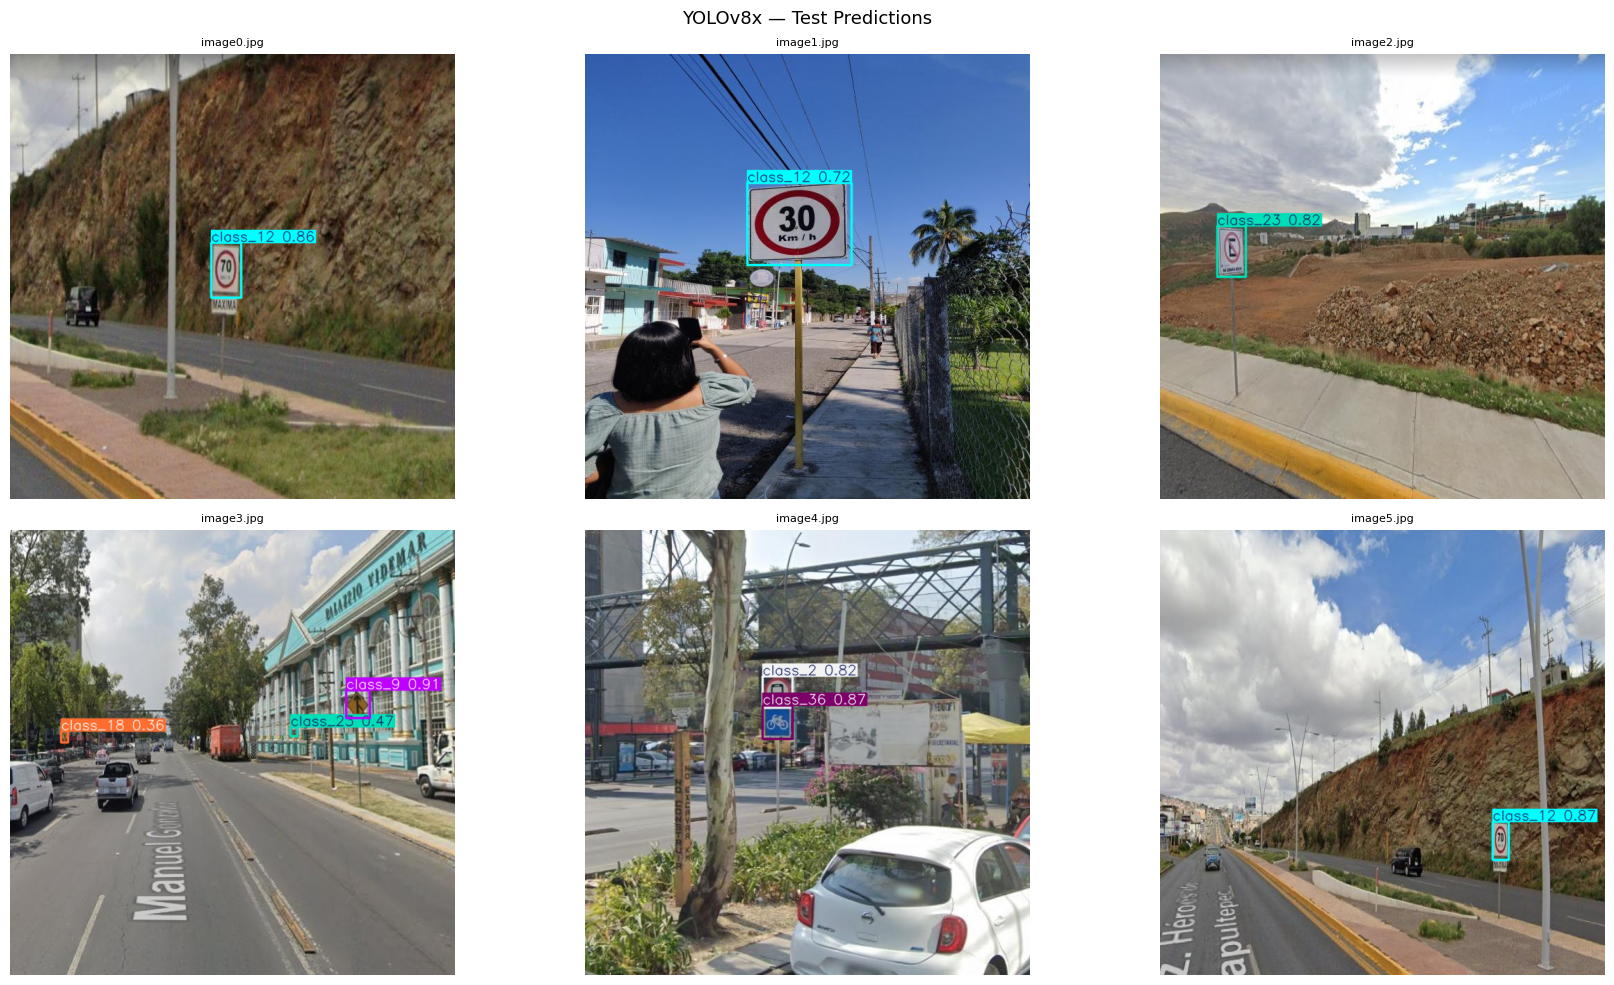

── YOLOv8x results.png


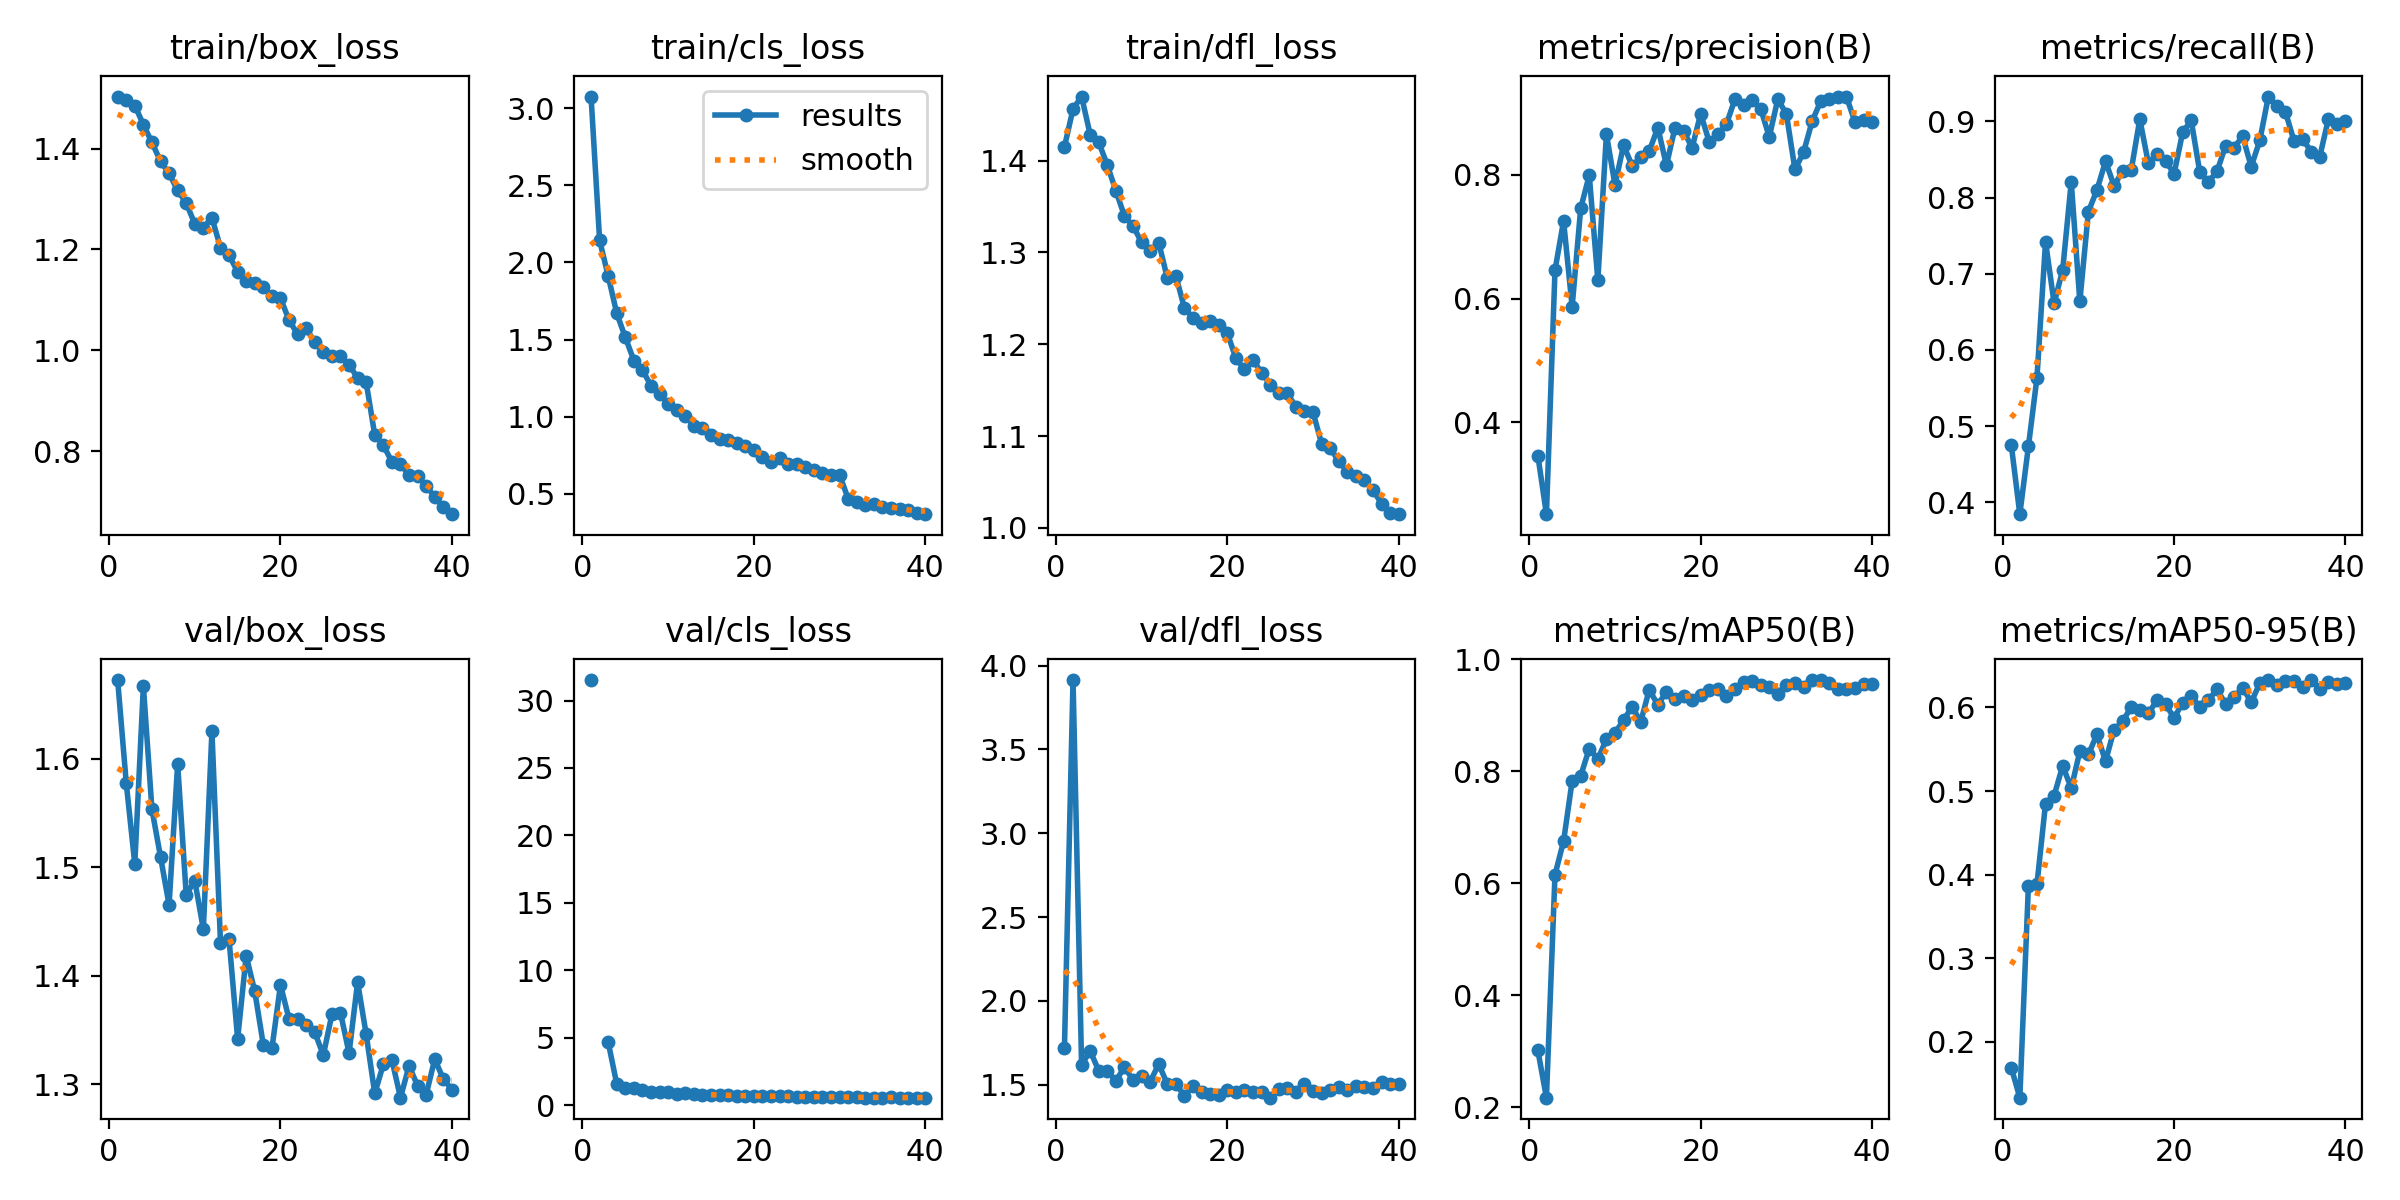

── YOLOv8x confusion_matrix_normalized.png


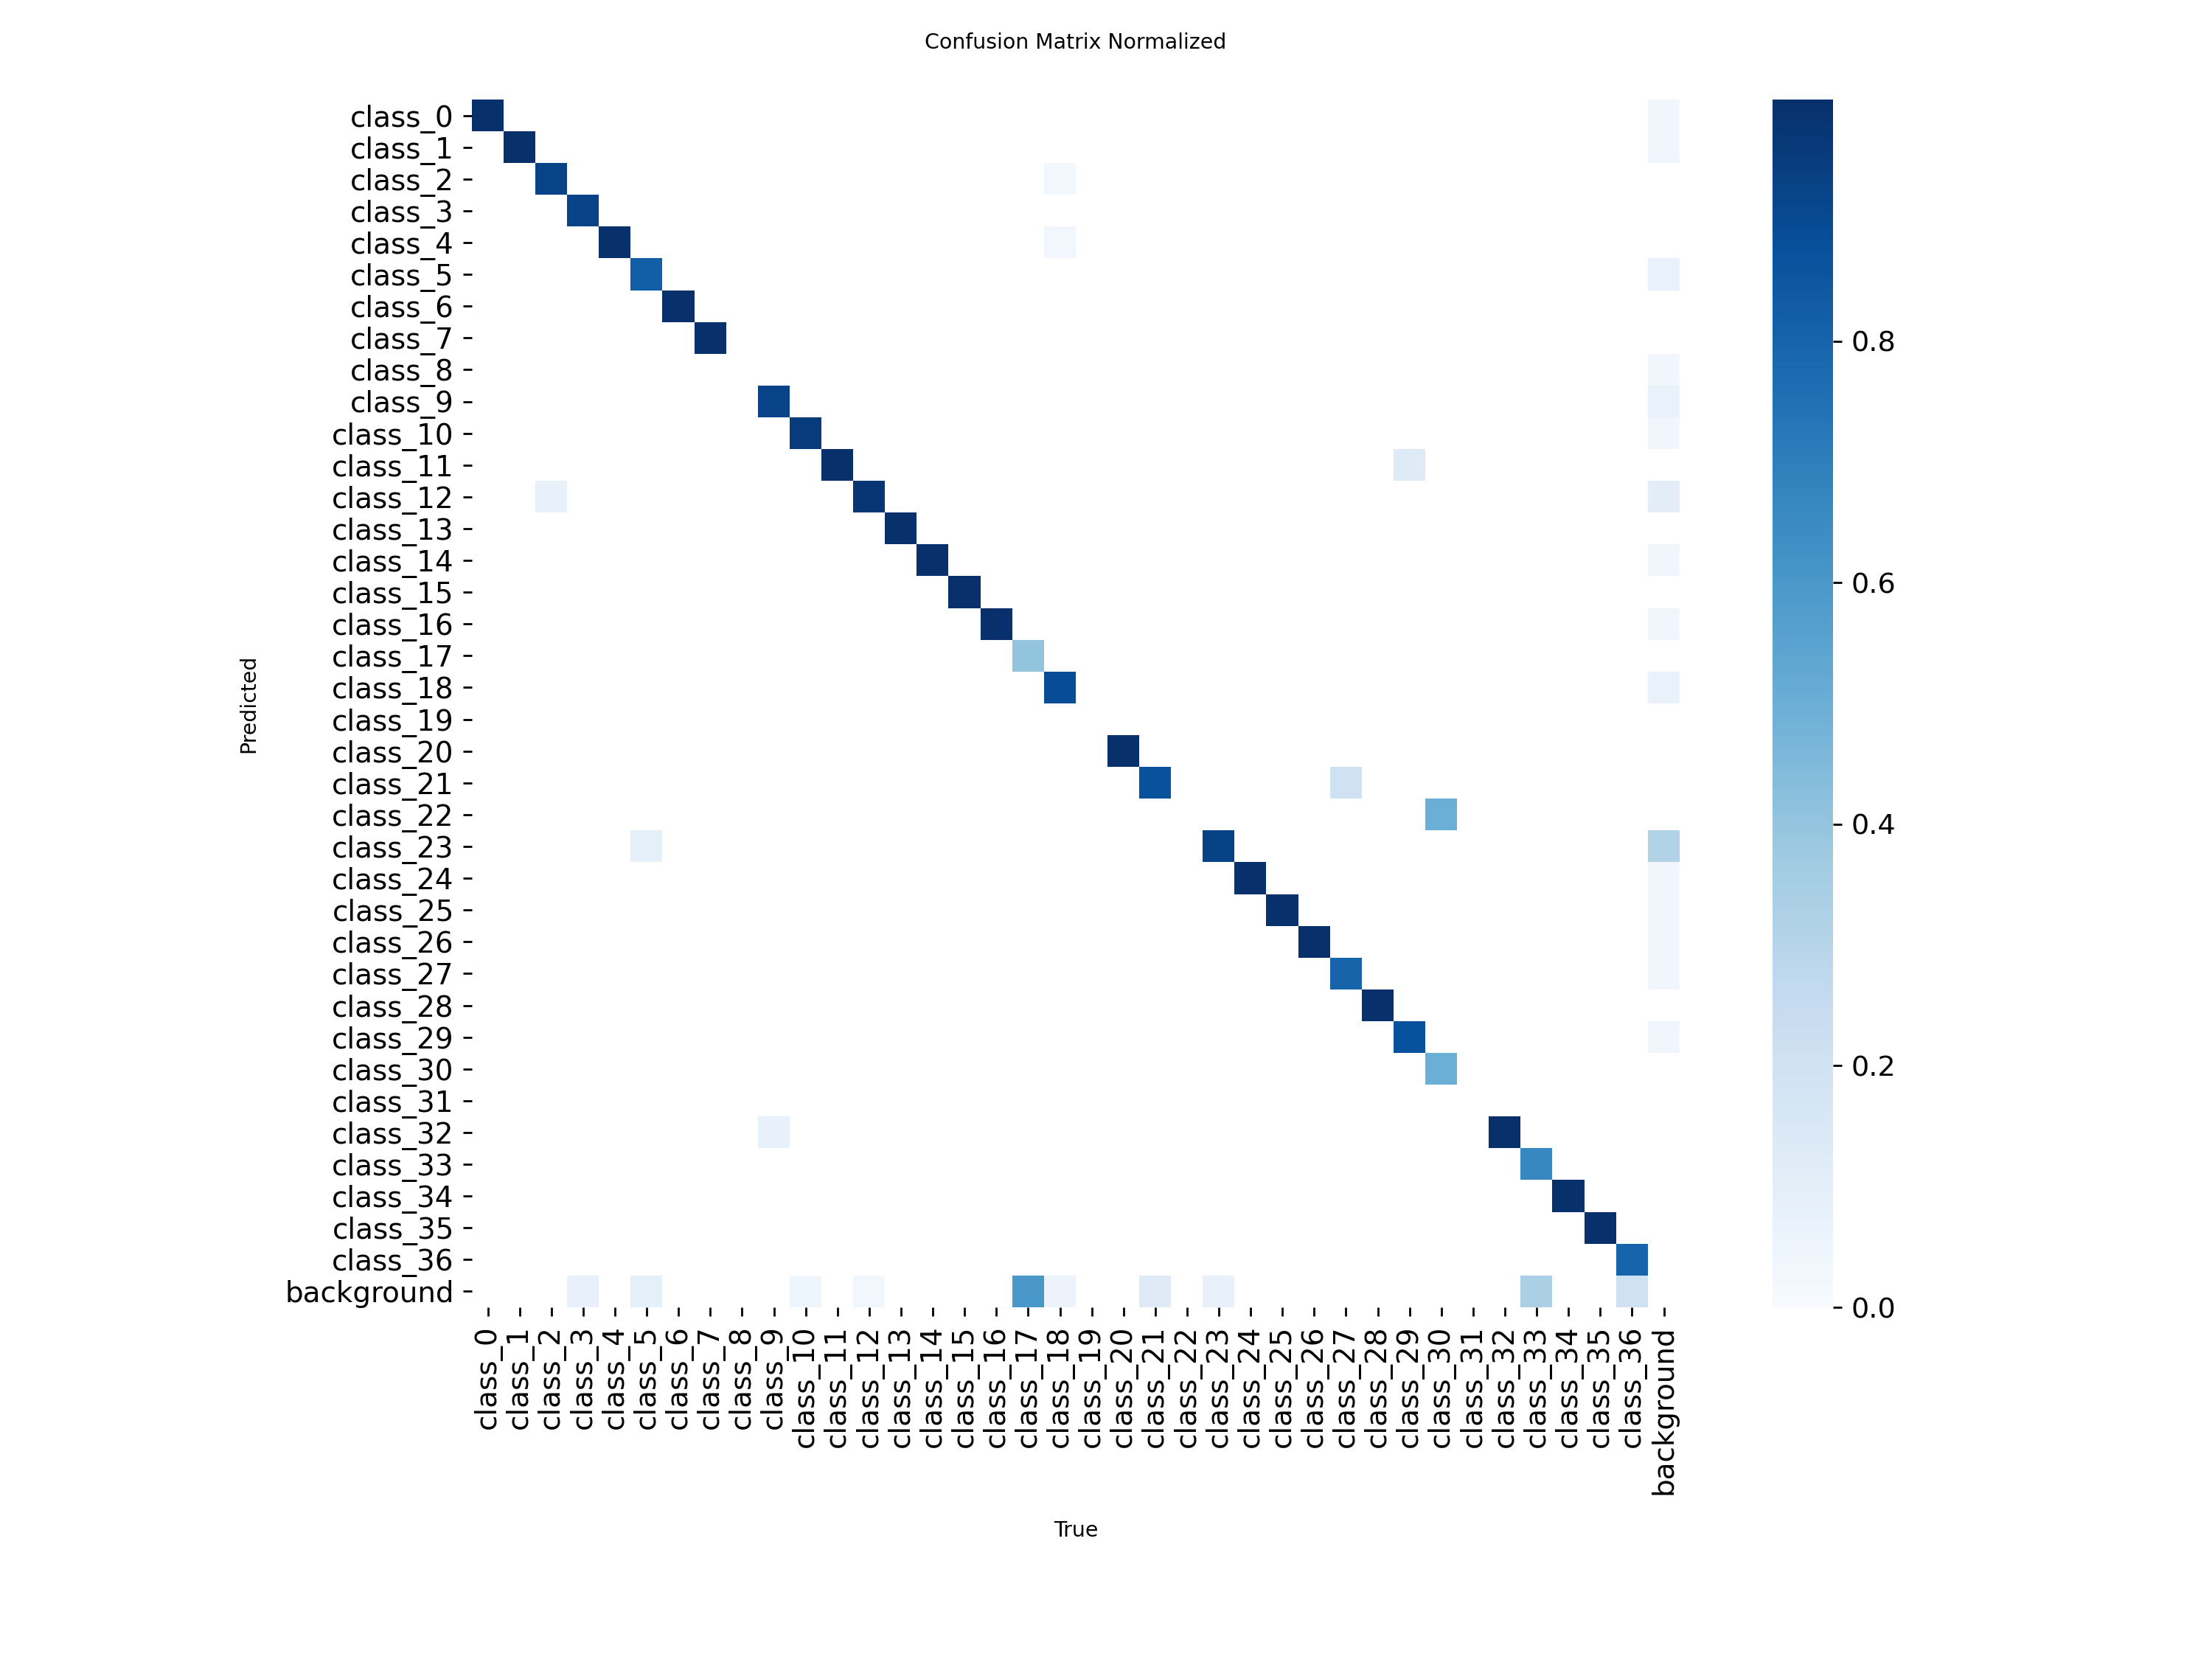

In [17]:
import glob, random, matplotlib.pyplot as plt, os
from pathlib import Path
from IPython.display import Image as IPImage, display

test_imgs = glob.glob(f'{DATASET_PATH}/images/test/*.jpg') + glob.glob(f'{DATASET_PATH}/images/test/*.png')
preds_v8x = model_v8x_eval.predict(
    source=random.sample(test_imgs, min(6, len(test_imgs))),
    imgsz=IMG_SIZE, conf=0.25, device=0, save=False, verbose=False
)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, r in zip(axes.flatten(), preds_v8x):
    ax.imshow(r.plot()[:,:,::-1]); ax.axis('off')
    ax.set_title(Path(r.path).name, fontsize=8)
plt.suptitle('YOLOv8x — Test Predictions', fontsize=13)
plt.tight_layout()
plt.savefig('/content/v8x_test_predictions.png', dpi=150)
plt.show()

run_dir_v8x = f'/content/runs/detect/{PROJECT_NAME}/{RUN_V8X}'
for plot in ['results.png', 'confusion_matrix_normalized.png', 'PR_curve.png', 'F1_curve.png']:
    p = os.path.join(run_dir_v8x, plot)
    if os.path.exists(p):
        print(f'── YOLOv8x {plot}')
        display(IPImage(p, width=900))

---
# 📊 Cell 24 — Head-to-Head Model Comparison

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect all results
results_summary = [
    {
        'Model'     : 'YOLOv11x',
        'Val mAP@50': metrics_v11x.box.map50 * 100,
        'Val mAP@50-95': metrics_v11x.box.map * 100,
        'Val Precision': metrics_v11x.box.mp,
        'Val Recall'   : metrics_v11x.box.mr,
        'Test mAP@50'  : test_v11x.box.map50 * 100,
        'Test mAP@50-95': test_v11x.box.map * 100,
    },
    {
        'Model'     : 'YOLOv9e',
        'Val mAP@50': metrics_v9e.box.map50 * 100,
        'Val mAP@50-95': metrics_v9e.box.map * 100,
        'Val Precision': metrics_v9e.box.mp,
        'Val Recall'   : metrics_v9e.box.mr,
        'Test mAP@50'  : test_v9e.box.map50 * 100,
        'Test mAP@50-95': test_v9e.box.map * 100,
    },
    {
        'Model'     : 'YOLOv8x',
        'Val mAP@50': metrics_v8x.box.map50 * 100,
        'Val mAP@50-95': metrics_v8x.box.map * 100,
        'Val Precision': metrics_v8x.box.mp,
        'Val Recall'   : metrics_v8x.box.mr,
        'Test mAP@50'  : test_v8x.box.map50 * 100,
        'Test mAP@50-95': test_v8x.box.map * 100,
    },
]

df = pd.DataFrame(results_summary).set_index('Model')
print('\n══════════════════════════════════════════════════')
print('          MULTI-MODEL COMPARISON SUMMARY')
print('══════════════════════════════════════════════════')
print(df.round(2).to_string())
print('══════════════════════════════════════════════════')

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#9b59b6', '#e67e22', '#2980b9']

for ax, col, title in [
    (axes[0], 'Val mAP@50',  'Validation mAP@50 (%)'),
    (axes[1], 'Test mAP@50', 'Test mAP@50 (%)'),
]:
    bars = ax.bar(df.index, df[col], color=colors, edgecolor='white', linewidth=1.2)
    ax.set_ylabel('mAP@50 (%)')
    ax.set_title(title)
    ax.set_ylim(0, 100)
    for bar, val in zip(bars, df[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('YOLOv11x vs YOLOv9e vs YOLOv8x — ReWaIn-MTS (40 epochs)', fontsize=13)
plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150)
plt.show()

# Find winner
best_model = df['Test mAP@50'].idxmax()
print(f'\n🏆 Best model on Test mAP@50: {best_model} ({df.loc[best_model, "Test mAP@50"]:.2f}%)')

NameError: name 'metrics_v11x' is not defined

## Cell 25 — Save All Runs to Google Drive

In [ ]:
import shutil, os

SAVE_DIR = f'/content/runs/detect/{PROJECT_NAME}'
os.makedirs(SAVE_DIR, exist_ok=True)

# Copy comparison plots
for f in [
    '/content/class_dist_comparison.png',
    '/content/class_dist_before.png',
    '/content/v11x_test_predictions.png',
    '/content/v9e_test_predictions.png',
    '/content/v8x_test_predictions.png',
    '/content/model_comparison.png',
]:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR)
        print(f'  ✅ Saved: {os.path.basename(f)}')

print(f'\n✅ All runs saved under: {SAVE_DIR}')
print(f'   YOLOv11x best.pt → {BEST_V11X}')
print(f'   YOLOv9e  best.pt → {BEST_V9E}')
print(f'   YOLOv8x  best.pt → {BEST_V8X}')

---
## 📋 Notebook Summary

| Cell | What it does |
|------|--------------|
| **2** | ⚡ Zips dataset on Drive → copies as single file → unzips locally (fast!) |
| **3** | Config — shared across all 3 models (40 epochs each) |
| **4** | 80/20 train/val split from local disk (seconds, not minutes) |
| **5** | Auto-discover class IDs, build `data.yaml` (shared) |
| **6** | Analyse class distribution & compute inverse-frequency weights |
| **7** | Oversample: minority classes duplicated to ≥30 annotations |
| **8** | Albumentations: 3 offline augmented variants per minority image |
| **11** | `BalancedTrainer` + `WeightedDetectionLoss` (optional Strategy 3) |
| **12–15** | 🅐 Train / Eval / Visualise **YOLOv11x** |
| **16–19** | 🅑 Train / Eval / Visualise **YOLOv9e** |
| **20–23** | 🅒 Train / Eval / Visualise **YOLOv8x** |
| **24** | 📊 Head-to-head comparison table + bar chart |
| **25** | 💾 Save all runs & plots to Drive |

### Troubleshooting
- **Dataset not found** → Add My Drive shortcut (Cell 2 instructions)
- **CUDA OOM** → `BATCH_SIZE = 8` in Cell 3 (v9e and v8x are heavier than v11m)
- **Resume after disconnect** → `YOLO('...last.pt').train(resume=True)`
- **Minority AP still low** → Raise `OVERSAMPLE_TARGET` to 50 in Cell 3
- **YOLOv9e download fails** → Run `!yolo export model=yolov9e.pt` first or download manually from Ultralytics releases